In [ ]:
# Project 3: Weather Data Analysis

**Executive Summary**  
- Analyzed daily weather data for 1 year  
- Average temperature: ~15–25°C (seasonal variation)  
- Seasonal patterns: Warmest in summer, coolest in winter  
- Rainfall: Mostly light, few heavy rain days  
- Extreme events: Very few days above 30°C or below 0°C  
- Recommendations:  
  - Plan outdoor activities in spring/summer  
  - Minimal flood risk based on rainfall distribution  
  - Monitor cold snaps in winter for heating needs

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_style("whitegrid")

In [9]:
# Load Melbourne daily min temperatures dataset (clean and working)
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"
df = pd.read_csv(url)

# Fix column names and convert date
df = df.rename(columns={'Date': 'DATE', 'Temp': 'Temp_min'})
df['DATE'] = pd.to_datetime(df['DATE'])

# Add month, year, season (Southern Hemisphere)
df['Month'] = df['DATE'].dt.month
df['Year'] = df['DATE'].dt.year
df['Season'] = df['Month'].apply(lambda m: 'Summer' if m in [12,1,2] else
                                 'Autumn' if m in [3,4,5] else
                                 'Winter' if m in [6,7,8] else 'Spring')

print("Loaded! Shape:", df.shape)
print("Date range:", df['DATE'].min().date(), "to", df['DATE'].max().date())
print("Columns:", df.columns.tolist())
print(df.head())

Loaded! Shape: (3650, 5)
Date range: 1981-01-01 to 1990-12-31
Columns: ['DATE', 'Temp_min', 'Month', 'Year', 'Season']
        DATE  Temp_min  Month  Year  Season
0 1981-01-01      20.7      1  1981  Summer
1 1981-01-02      17.9      1  1981  Summer
2 1981-01-03      18.8      1  1981  Summer
3 1981-01-04      14.6      1  1981  Summer
4 1981-01-05      15.8      1  1981  Summer


In [10]:
print("\n=== Data Quality ===")
print("Missing values:\n", df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

print("\n=== Temperature Statistics ===")
print(df['Temp_min'].describe().round(2))

print("\nAverage min temperature by season:")
print(df.groupby('Season')['Temp_min'].mean().round(2))


=== Data Quality ===
Missing values:
 DATE        0
Temp_min    0
Month       0
Year        0
Season      0
dtype: int64
Duplicates: 0

=== Temperature Statistics ===
count    3650.00
mean       11.18
std         4.07
min         0.00
25%         8.30
50%        11.00
75%        14.00
max        26.30
Name: Temp_min, dtype: float64

Average min temperature by season:
Season
Autumn    12.17
Spring    10.59
Summer    14.73
Winter     7.29
Name: Temp_min, dtype: float64


C:\Users\boyal\AppData\Local\Temp\ipykernel_20312\1068366105.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Season', y='Temp_min', data=df, palette='coolwarm', ax=axes[0,1])
C:\Users\boyal\AppData\Local\Temp\ipykernel_20312\1068366105.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monthly_avg.index, y=monthly_avg.values, palette='viridis', ax=axes[1,1])


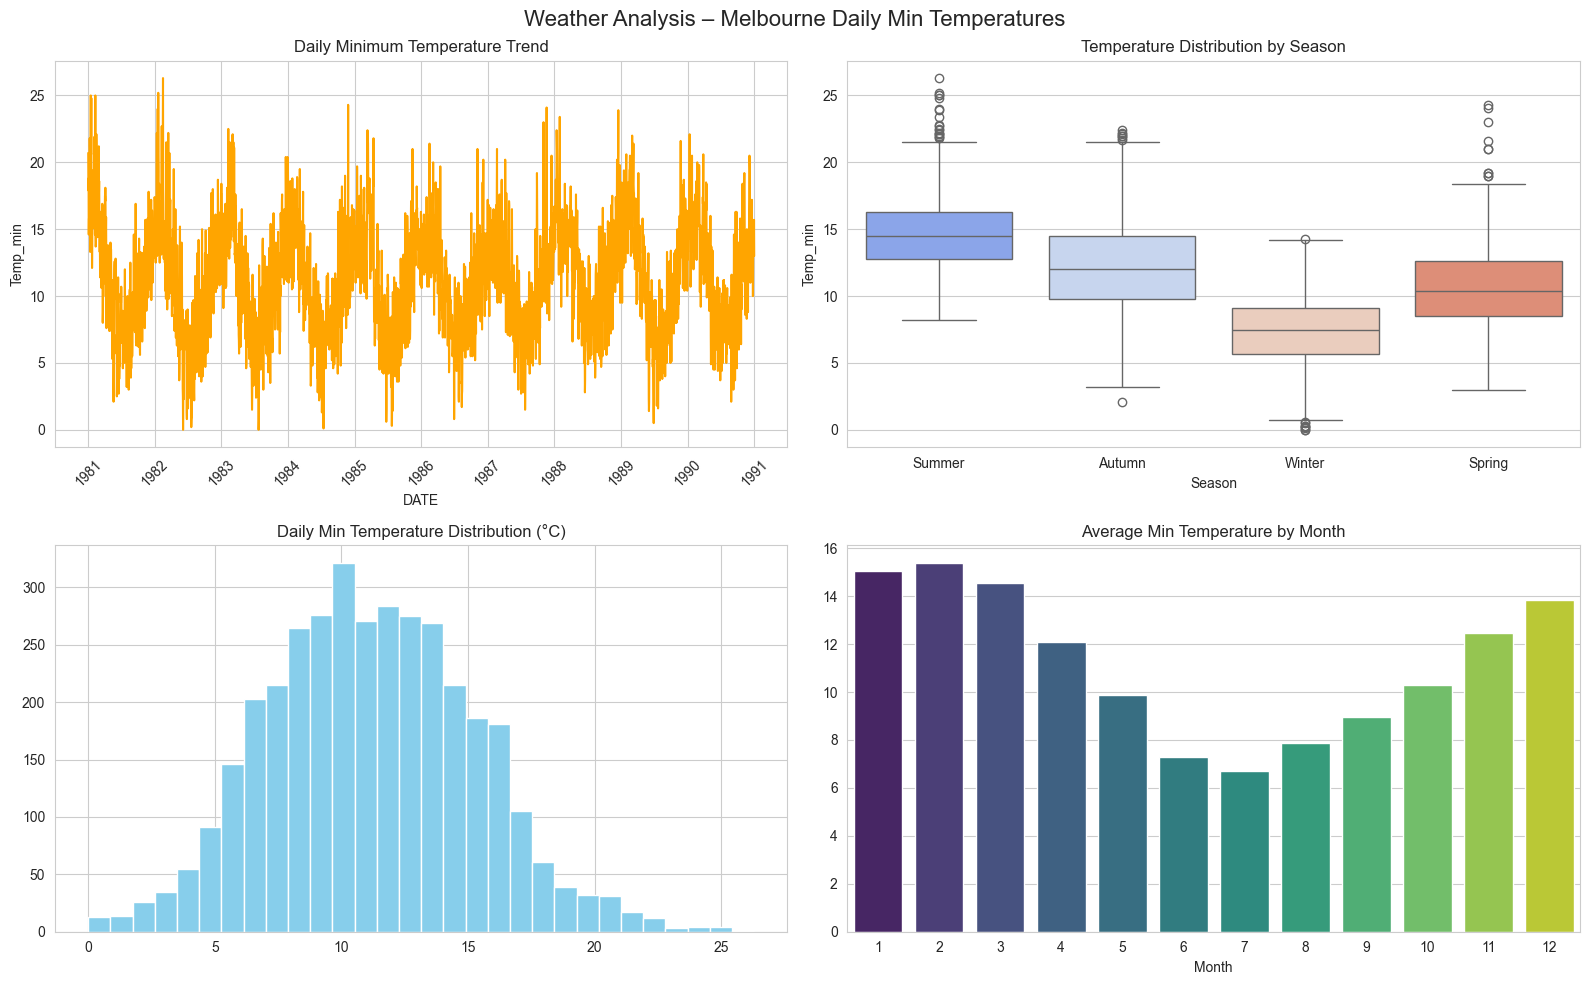

Visuals saved!


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Weather Analysis – Melbourne Daily Min Temperatures', fontsize=16)

# 1. Temperature Trend (Line)
sns.lineplot(data=df, x='DATE', y='Temp_min', color='orange', ax=axes[0,0])
axes[0,0].set_title('Daily Minimum Temperature Trend')
axes[0,0].tick_params(axis='x', rotation=45)

# 2. Temperature by Season (Boxplot)
sns.boxplot(x='Season', y='Temp_min', data=df, palette='coolwarm', ax=axes[0,1])
axes[0,1].set_title('Temperature Distribution by Season')

# 3. Temperature Histogram
df['Temp_min'].hist(bins=30, color='skyblue', ax=axes[1,0])
axes[1,0].set_title('Daily Min Temperature Distribution (°C)')

# 4. Monthly Average (Bar)
monthly_avg = df.groupby('Month')['Temp_min'].mean()
sns.barplot(x=monthly_avg.index, y=monthly_avg.values, palette='viridis', ax=axes[1,1])
axes[1,1].set_title('Average Min Temperature by Month')
axes[1,1].set_xlabel('Month')

plt.tight_layout()
plt.show()

fig.savefig('weather_visuals.png', dpi=300, bbox_inches='tight')
print("Visuals saved!")